# Insurance Customer Response Prediction

## Import Libraries

In [6]:
# Load dataset
df = pd.read_csv('../data/train.csv')

# Display first 5 rows
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## Basic Dataset Information

In [7]:
# Dataset shape
print("Shape of Dataset:", df.shape)

# Dataset information
df.info()

# First 5 rows
df.head()

Shape of Dataset: (381109, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [8]:
# Statistical Summary
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [9]:
# Check missing values
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64


## Exploratory Data Analysis (EDA)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

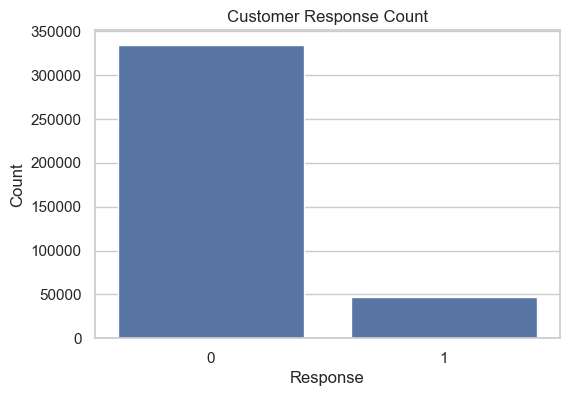

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df)
plt.title('Customer Response Count')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()

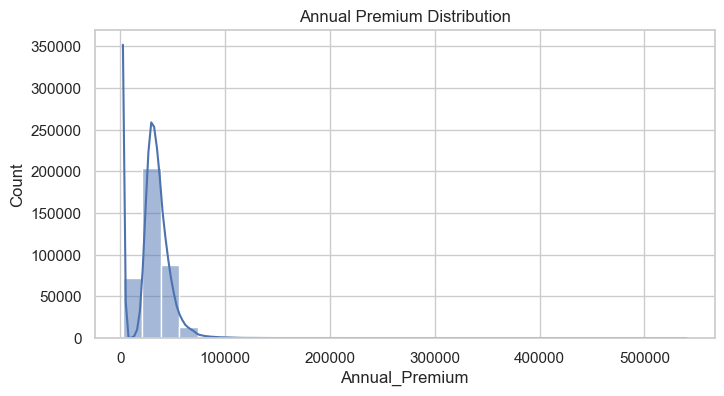

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df['Annual_Premium'], kde=True, bins=30)
plt.title('Annual Premium Distribution')
plt.show()

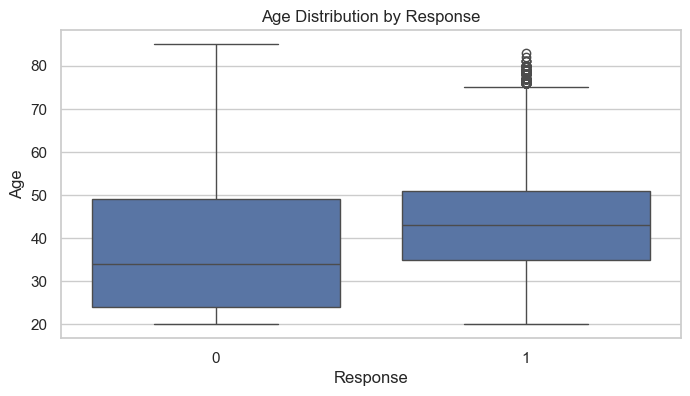

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Response', y='Age', data=df)
plt.title('Age Distribution by Response')
plt.show()

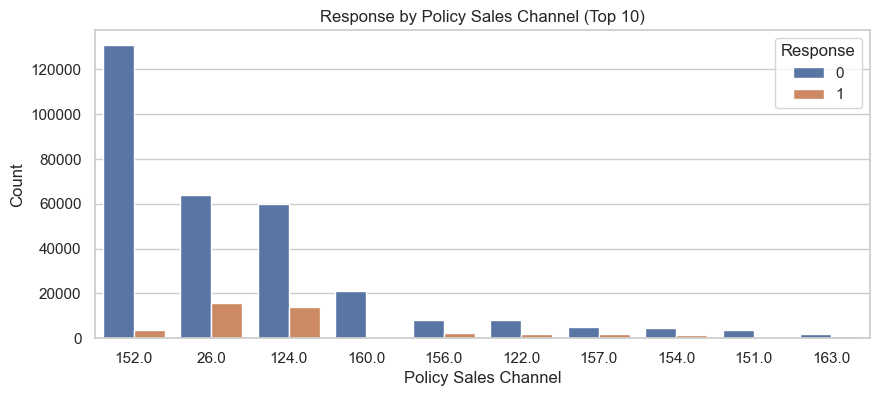

In [15]:
plt.figure(figsize=(10,4))

sns.countplot(
    x='Policy_Sales_Channel',
    hue='Response',
    data=df,
    order=df['Policy_Sales_Channel'].value_counts().index[:10]
)

plt.title('Response by Policy Sales Channel (Top 10)')
plt.xlabel('Policy Sales Channel')
plt.ylabel('Count')
plt.show()

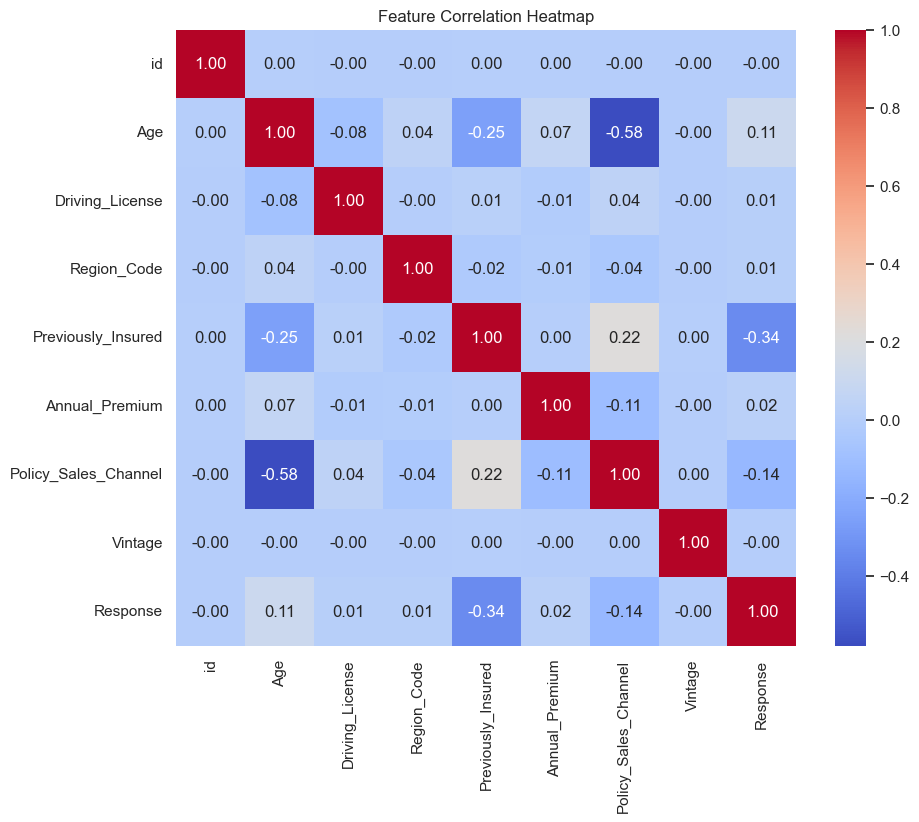

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Feature Correlation Heatmap')
plt.show()

## Data Preprocessing

In [17]:
# Convert categorical variables to numerical values

df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes':1, 'No':0})

# One-Hot Encode Vehicle_Age
df = pd.get_dummies(
    df,
    columns=['Vehicle_Age'],
    drop_first=True
)

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years
0,1,1,44,1,28.0,0,1,40454.0,26.0,217,1,False,True
1,2,1,76,1,3.0,0,0,33536.0,26.0,183,0,False,False
2,3,1,47,1,28.0,0,1,38294.0,26.0,27,1,False,True
3,4,1,21,1,11.0,1,0,28619.0,152.0,203,0,True,False
4,5,0,29,1,41.0,1,0,27496.0,152.0,39,0,True,False


## Feature Engineering

In [18]:
# Create Senior Driver feature

df['Senior_Driver'] = np.where(df['Age'] >= 60, 1, 0)

# Create Age Bins

df['Age_Bin'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]
)

# Convert Age_Bin to numeric

df['Age_Bin'] = df['Age_Bin'].astype(int)

# Preview

df[['Age', 'Driving_License', 'Senior_Driver', 'Age_Bin']].head()

,Age,Driving_License,Senior_Driver,Age_Bin
0,44,1,0,1
1,76,1,1,3
2,47,1,0,2
3,21,1,0,0
4,29,1,0,0


## Train-Test Split & Feature Scaling

In [19]:
from sklearn.model_selection import train_test_split

# Separate features and target

X = df.drop(columns=['Response'])
y = df['Response']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (304887, 14)
X_test shape: (76222, 14)


In [20]:
from sklearn.preprocessing import StandardScaler

# Scale data for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


## Model Training

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize models

log_model = LogisticRegression(max_iter=2000)

dt_model = DecisionTreeClassifier(
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

In [22]:
# Train models

log_model.fit(X_train_scaled, y_train)

dt_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


## Model Evaluation

In [23]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Logistic Regression Predictions
log_pred = log_model.predict(X_test_scaled)

# Decision Tree Predictions
dt_pred = dt_model.predict(X_test)

# Random Forest Predictions
rf_pred = rf_model.predict(X_test)

In [24]:
# Logistic Regression

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))

print(
    "Classification Report:\n",
    classification_report(
        y_test,
        log_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, log_pred)
)

Logistic Regression
Accuracy: 0.8750623179659416
Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.00      0.00      0.00      9523

    accuracy                           0.88     76222
   macro avg       0.44      0.50      0.47     76222
weighted avg       0.77      0.88      0.82     76222

ROC-AUC Score: 0.5


In [25]:
# Decision Tree

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))

print(
    "Classification Report:\n",
    classification_report(
        y_test,
        dt_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, dt_pred)
)

Decision Tree
Accuracy: 0.8221642045603631
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90     66699
           1       0.29      0.30      0.30      9523

    accuracy                           0.82     76222
   macro avg       0.60      0.60      0.60     76222
weighted avg       0.82      0.82      0.82     76222

ROC-AUC Score: 0.5998480642905202


In [26]:
# Random Forest

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))

print(
    "Classification Report:\n",
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, rf_pred)
)

Random Forest
Accuracy: 0.8692897063839836
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     66699
           1       0.39      0.08      0.14      9523

    accuracy                           0.87     76222
   macro avg       0.64      0.53      0.53     76222
weighted avg       0.82      0.87      0.83     76222

ROC-AUC Score: 0.5321679814335516


In [27]:
# Compare all models

models = {
    'Logistic Regression': log_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

for name, model in models.items():

    print(f"\n--- {name} ---")

    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print(
        "Classification Report:\n",
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    print(
        "Confusion Matrix:\n",
        confusion_matrix(y_test, y_pred)
    )


--- Logistic Regression ---
Accuracy: 0.8750623179659416
Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.00      0.00      0.00      9523

    accuracy                           0.88     76222
   macro avg       0.44      0.50      0.47     76222
weighted avg       0.77      0.88      0.82     76222

Confusion Matrix:
 [[66699     0]
 [ 9523     0]]

--- Decision Tree ---
Accuracy: 0.8221642045603631
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90     66699
           1       0.29      0.30      0.30      9523

    accuracy                           0.82     76222
   macro avg       0.60      0.60      0.60     76222
weighted avg       0.82      0.82      0.82     76222

Confusion Matrix:
 [[59777  6922]
 [ 6633  2890]]

--- Random Forest ---
Accuracy: 0.8692897063839836
Classification Report:
             

## Feature Importance Analysis

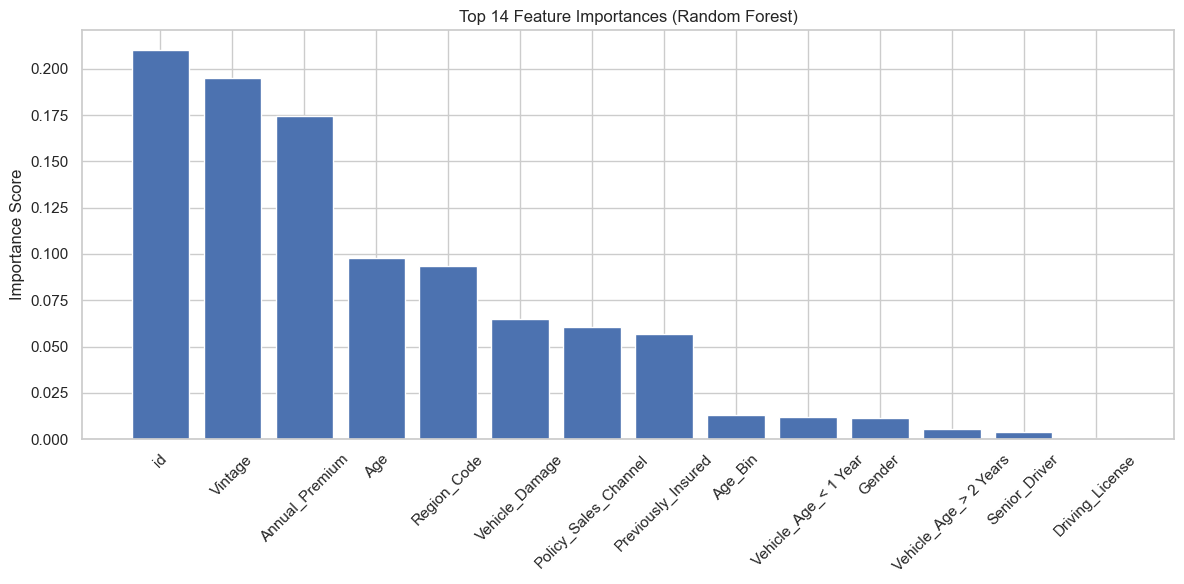

In [29]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_names = X_train.columns

indices = np.argsort(importances)[::-1]

top_n = min(15, len(importances))

plt.figure(figsize=(12,6))

plt.title(
    f"Top {top_n} Feature Importances (Random Forest)"
)

plt.bar(
    range(top_n),
    importances[indices][:top_n],
    align="center"
)

plt.xticks(
    range(top_n),
    [feature_names[i] for i in indices][:top_n],
    rotation=45
)

plt.ylabel("Importance Score")

plt.tight_layout()

plt.show()

## Save Models

In [30]:
import joblib

# Save models to files

joblib.dump(log_model, 'logistic_model.pkl')

joblib.dump(dt_model, 'decision_tree_model.pkl')

joblib.dump(rf_model, 'random_forest_model.pkl')

# Save scaler

joblib.dump(scaler, 'scaler.pkl')

print("Models and scaler saved successfully!")

Models and scaler saved successfully!


In [31]:
import os

print(os.listdir())

['decision_tree_model.pkl', 'insurance_response_prediction.ipynb', 'logistic_model.pkl', 'random_forest_model.pkl', 'scaler.pkl']
